In [132]:
# Librairies
from fismi import sdxData as sdx
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(suppress=True, precision=4)
plt.rcParams["figure.figsize"] = (9, 5)

# Data
## Definition
We collect the HICP and its components on a monthly grid for the EA. The data is provided by the European Central Bank (SDW). The series are adjusted for hollidays and seasonality, available on a monthly frequency since 1997-01 and expressed in base 100 = 2025. 

The HICP index is broken down following the European Classification of Individual Consumption According to Purpose (ECOICOP) that you can find [here (ECOICOP 2)](https://showvoc.op.europa.eu/#/datasets/ESTAT_European_Classification_of_Individual_Consumption_according_to_Purpose_version_2__ECOICOP_2/unknown/data).

We also collect ECOICOP 2 item weights from the [Eurostat PRC_HICP_INW database](https://ec.europa.eu/eurostat/databrowser/view/prc_hicp_inw__custom_22798527/default/table). The weights sum to 1,000 and represent the share that the *representative EA household* spend into each of the HICP's items.

### Index sub-components

In [133]:
### ECB Website = ECOICOP 1 around 425 series 

## WS URL and dataset query
## Metadata : 
## HICP = Database
## M    = Frequency (monthly)
## U2   = EA changing composition
## Y    = Working days and seasonally adjusted series
## 4D0  = European Commission (Eurostat)
## 4F0  = ECB (SDW)
## INX  = Index

url = "https://data-api.ecb.europa.eu/service/data/HICP/M.U2.N..4D0.INX"
dfIdx, tempIdx = sdx.getdata(url, colName="KEY", params=None)



/Users/lea_gosselin/GitRepo/ismi-index/.venv/lib/python3.11/site-packages/urllib3/connectionpool.py:1110: InsecureRequestWarning: Unverified HTTPS request is being made to host 'data-api.ecb.europa.eu'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
/Users/lea_gosselin/GitRepo/ismi-index/fismi/sdxData.py:18: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  temp = pd.read_csv(io.StringIO(response.text))


In [134]:
url = "https://data-api.ecb.europa.eu/service/data/HICP/A.U2.N...INW"
df, dfTemp = sdx.getdata(url, colName="KEY", params=None)

/Users/lea_gosselin/GitRepo/ismi-index/.venv/lib/python3.11/site-packages/urllib3/connectionpool.py:1110: InsecureRequestWarning: Unverified HTTPS request is being made to host 'data-api.ecb.europa.eu'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


In [142]:
print(f"ECB provider, number of ICP items' weights {len(dfTemp['ICP_ITEM'].unique())}")
print(f"ECB provider, number of ICP indexes {len(tempIdx['ICP_ITEM'].unique())}")

ECB provider, number of ICP items' weights 471
ECB provider, number of ICP indexes 465


In [136]:
### Eurostat = ECOICOP 2 but 416 and starts later

## Metadata : 
## prc_hicp_midx = Database
## M             = Frequency (monthly)
## EA            = EA changing composition
## I15           = Base 2015 = 100

# url = "https://ec.europa.eu/eurostat/api/dissemination/sdmx/2.1/data/prc_hicp_midx/M.I15..EA"
# dfIdx, tempIdx = sdx.getdata(url, colName="coicop", headers=None)
# tempIdx

In [ ]:
# Get ECOICOP sub-keys : Index
uniKeys = tempIdx.KEY.unique()
unEcoicop = [[i, i.split(".")[4]] for i in uniKeys]
temp = pd.DataFrame(unEcoicop, columns=["KEY", "ecoicop"])
tempIdx = pd.merge(tempIdx, temp, how="left", on="KEY")
tempIdx

# Convert in float identifiers
tempIdx["ecoicop"] = tempIdx["ecoicop"].str.rstrip('0')

# Deal with HICP.M.U2.N.000000.4D0.INX (HICP Index - Total) and "Education services"
tempIdx.loc[tempIdx.KEY == "HICP.M.U2.N.000000.4D0.INX", "ecoicop"] = '00'
tempIdx.loc[tempIdx.KEY == "HICP.M.U2.N.100000.4D0.INX", "ecoicop"] = '10'

# Dates management
tempIdx['TIME_PERIOD'] = pd.to_datetime(tempIdx['TIME_PERIOD'].astype(str), format='%Y-%m')

# Rename 
tempIdx = tempIdx.rename(columns={"OBS_VALUE":"INX"})

In [113]:
# Resize
tempIdx = tempIdx[["KEY","TITLE","TIME_PERIOD","ecoicop","INX"]]

### Items weights

In [114]:
url = "https://ec.europa.eu/eurostat/api/dissemination/sdmx/2.1/data/prc_hicp_inw/A..EA"
dfW, tempW = sdx.getdata(url, colName="coicop", headers=None)

/Users/lea_gosselin/GitRepo/ismi-index/.venv/lib/python3.11/site-packages/urllib3/connectionpool.py:1110: InsecureRequestWarning: Unverified HTTPS request is being made to host 'ec.europa.eu'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


In [115]:
# Get ECOICOP sub-keys : Weights
uniKeysW = tempW.coicop.unique()
unEcoicopW = [[i, i.replace("CP","")]for i in uniKeysW]
temp = pd.DataFrame(unEcoicopW, columns=["coicop","ecoicop"])
tempW = pd.merge(tempW, temp, how="left", on="coicop")

In [116]:
# Convert to the first month of each year : January-YY
tempW['TIME_PERIOD'] = pd.to_datetime(tempW['TIME_PERIOD'].astype(str) + "-01", format='%Y-%m')

# Rename
tempW = tempW.rename(columns={"OBS_VALUE":"WEIGHTS"})

In [117]:
# We merge both dataframes
dFinal = pd.merge(
    tempIdx, tempW[["TIME_PERIOD","ecoicop","WEIGHTS"]],
    how="left",
    left_on=["TIME_PERIOD", "ecoicop"],
    right_on=["TIME_PERIOD", "ecoicop"]
)

# Forward fill
dFinal['WEIGHTS'].ffill(inplace=True)
dFinal

# Exclude 13th component (ECOICOP 2) : Personal Care, Social Protection, Miscellaneous Goods and Services. Included as of 2026-01.
# dFinal = dFinal[~dFinal["ecoicop"].str.startswith("13")].dropna()

/var/folders/zg/2lsdtr0j4fq844zjvs8ybwfc0000gn/T/ipykernel_16107/4155766839.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dFinal['WEIGHTS'].ffill(inplace=True)


,KEY,TITLE,TIME_PERIOD,ecoicop,INX,WEIGHTS
0,HICP.M.U2.N.000000.4D0.INX,HICP Inflation rate - Total - Index,1990-01-01,00,NaN,NaN
1,HICP.M.U2.N.000000.4D0.INX,HICP Inflation rate - Total - Index,1990-02-01,00,NaN,NaN
2,HICP.M.U2.N.000000.4D0.INX,HICP Inflation rate - Total - Index,1990-03-01,00,NaN,NaN
3,HICP.M.U2.N.000000.4D0.INX,HICP Inflation rate - Total - Index,1990-04-01,00,NaN,NaN
4,HICP.M.U2.N.000000.4D0.INX,HICP Inflation rate - Total - Index,1990-05-01,00,NaN,NaN
...,...,...,...,...,...,...
111824,HICP.M.U2.N.XSEAS0.4D0.INX,HICP Inflation rate - Total excluding seasonal...,2026-03-01,XSEAS,101.93,456.49
111825,HICP.M.U2.N.XSEAS0.4D0.INX,HICP Inflation rate - Total excluding seasonal...,2026-04-01,XSEAS,102.96,456.49
111826,HICP.M.U2.N.XSEAS0.4D0.INX,HICP Inflation rate - Total excluding seasonal...,2026-05-01,XSEAS,103.08,456.49
111827,HICP.M.U2.N.XSEAS0.4D0.INX,HICP Inflation rate - Total excluding seasonal...,2026-06-01,XSEAS,103.03,456.49


In [118]:
# Create levels from 0 to 5
is_convertible = pd.to_numeric(dFinal['ecoicop'], errors='coerce').notna()
nb_car = dFinal['ecoicop'].str.len()-1
dFinal['Niveau'] = np.where(is_convertible, "Niveau " + nb_car.astype(str), np.nan)

# For HICP Total gets Level 0
dFinal.loc[dFinal["ecoicop"]=='00',"Niveau"] = "Niveau 0"
dFinal = dFinal.dropna()
dFinal["SHARE"] = dFinal["WEIGHTS"] / 1000
dFinal["wINX"] =  dFinal["INX"]*dFinal["SHARE"]
dFinal

/var/folders/zg/2lsdtr0j4fq844zjvs8ybwfc0000gn/T/ipykernel_16107/2377005975.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dFinal["SHARE"] = dFinal["WEIGHTS"] / 1000
/var/folders/zg/2lsdtr0j4fq844zjvs8ybwfc0000gn/T/ipykernel_16107/2377005975.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dFinal["wINX"] =  dFinal["INX"]*dFinal["SHARE"]


,KEY,TITLE,TIME_PERIOD,ecoicop,INX,WEIGHTS,Niveau,SHARE,wINX
72,HICP.M.U2.N.000000.4D0.INX,HICP Inflation rate - Total - Index,1996-01-01,00,55.12,1000.00,Niveau 0,1.00000,55.120000
73,HICP.M.U2.N.000000.4D0.INX,HICP Inflation rate - Total - Index,1996-02-01,00,55.37,1000.00,Niveau 0,1.00000,55.370000
74,HICP.M.U2.N.000000.4D0.INX,HICP Inflation rate - Total - Index,1996-03-01,00,55.57,1000.00,Niveau 0,1.00000,55.570000
75,HICP.M.U2.N.000000.4D0.INX,HICP Inflation rate - Total - Index,1996-04-01,00,55.66,1000.00,Niveau 0,1.00000,55.660000
76,HICP.M.U2.N.000000.4D0.INX,HICP Inflation rate - Total - Index,1996-05-01,00,55.79,1000.00,Niveau 0,1.00000,55.790000
...,...,...,...,...,...,...,...,...,...
94429,HICP.M.U2.N.139090.4D0.INX,HICP Inflation rate - Other services n.e.c. (S...,2026-03-01,13909,102.27,15.57,Niveau 4,0.01557,1.592344
94430,HICP.M.U2.N.139090.4D0.INX,HICP Inflation rate - Other services n.e.c. (S...,2026-04-01,13909,102.51,15.57,Niveau 4,0.01557,1.596081
94431,HICP.M.U2.N.139090.4D0.INX,HICP Inflation rate - Other services n.e.c. (S...,2026-05-01,13909,102.82,15.57,Niveau 4,0.01557,1.600907
94432,HICP.M.U2.N.139090.4D0.INX,HICP Inflation rate - Other services n.e.c. (S...,2026-06-01,13909,102.93,15.57,Niveau 4,0.01557,1.602620


**Careful :** Several dichotomies ; Ecoicop 1 does not account for the 13th component in the HICP - All Items (Personal care, social protection and miscellaneous goods and services) hence, the weights sum to 1015 (including the 13th component) instead of 1000. Moreover, the weights have been revised in 2015, see the differences in the HICP "fit" before and after the revision. 

In [120]:
dFinal.loc[dFinal.TIME_PERIOD == "2025-01-01 00:00:00",["Niveau","TITLE"]].groupby("Niveau").count()

,TITLE
Niveau,
Niveau 0,1
Niveau 1,13
Niveau 2,48
Niveau 3,125
Niveau 4,215
Niveau 5,11


In [87]:
# Niveau 0 c'est l'HICP Total, doit être composé par le Niveau 1
dfNiv1 = dFinal[dFinal.Niveau == "Niveau 1"].pivot(index="TIME_PERIOD", columns="ecoicop", values="wINX")
wNiv1 = dfNiv1.sum(axis=1)

# Niveau 2
dfNiv2 = dFinal[dFinal.Niveau == "Niveau 2"].pivot(index="TIME_PERIOD", columns="ecoicop", values="wINX")
wNiv2 = dfNiv2.sum(axis=1)


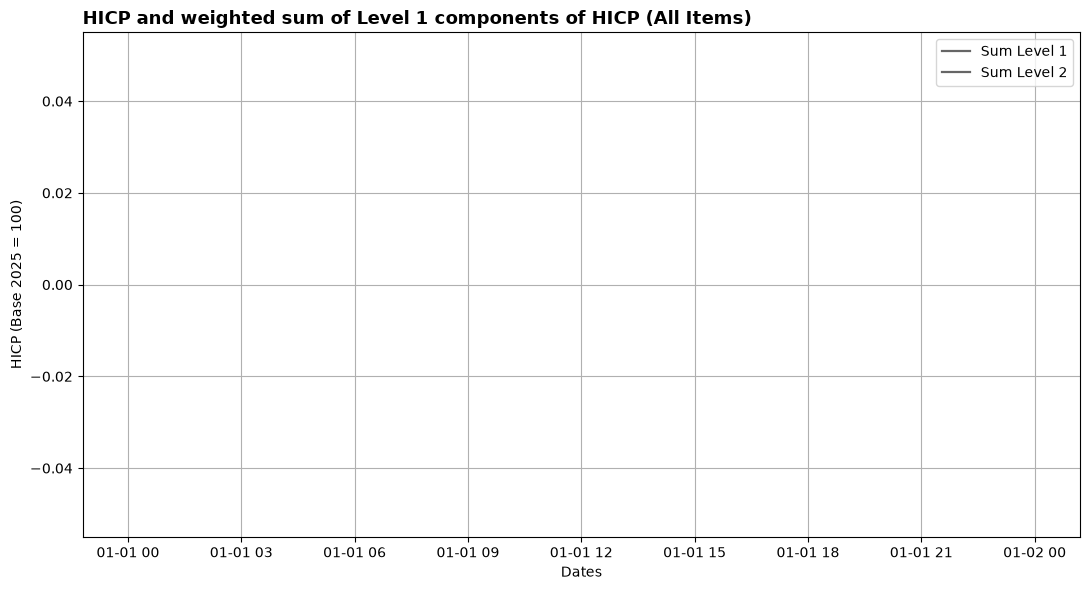

In [91]:
# Comparaison
# Plot...
fig, ax = plt.subplots(figsize=(11, 6))

x_axis = wNiv1.index

ax.plot(x_axis, wNiv1.values, color="black", lw=1.6, alpha=0.6, label="Sum Level 1")
ax.plot(x_axis, wNiv2.values, color="black", lw=1.6, alpha=0.6, label="Sum Level 2")

# ax.plot(x_axis, dFinal.loc[dFinal.ecoicop == "00", "wINX"].values, color="#4C72B0", lw=1.6, ls="--", label=f"Level 0")
ax.set_title("HICP and weighted sum of Level 1 components of HICP (All Items)",
              fontsize=13, fontweight="bold", loc="left")
ax.set_xlabel("Dates")
ax.set_ylabel("HICP (Base 2025 = 100)")
ax.legend(loc="best", fontsize=10)
plt.grid()
plt.tight_layout()
plt.show()

In [ ]:
# Create shares, must sum to 1
dFinal["SHARE"] = dFinal["WEIGHTS"]

for i in range(1,len(dFinal.Niveau.unique())):
    col = "Niveau " + i.str()
    mask = (dFinal.Niveau == col)
    
    # Compute shares
    dFinal.loc[mask, "SHARE"] = 


In [10]:
dFinal.loc[dFinal.Niveau == "Niveau 1", ["TITLE","ecoicop"]].drop_duplicates()

,TITLE,ecoicop
440,HICP Inflation rate - Food and non-alcoholic b...,01
15574,"HICP Inflation rate - Alcoholic beverages, tob...",02
18731,HICP Inflation rate - Clothing and footwear - ...,03
23310,"HICP Inflation rate - Housing, water, electric...",04
31620,"HICP Inflation rate - Furnishings, household e...",05
41126,HICP Inflation rate - Health - Index,06
48408,HICP Inflation rate - Transport - Index,07
58532,HICP Inflation rate - Information and communic...,08
65216,"HICP Inflation rate - Recreation, sport and cu...",09
79703,HICP Inflation rate - Education services - Index,10


In [11]:
# The sum over Niveau N weights must equal Niveau N-1 weight
df = dFinal[dFinal.Niveau == "Niveau 1"].pivot(index="TIME_PERIOD", columns="ecoicop", values="WEIGHTS")
df.sum(axis=1)

TIME_PERIOD
1996-01-01    1015.57
1996-02-01    1015.57
1996-03-01    1015.57
1996-04-01    1015.57
1996-05-01    1015.57
               ...   
2026-03-01    1015.57
2026-04-01    1015.57
2026-05-01    1015.57
2026-06-01    1015.57
2026-07-01    1015.57
Length: 367, dtype: float64